# 06 — Main Factorial: Mechanisms × Geometry

**Research question.** Holding budget and intercept fixed at the pilot-locked values, how do the three tie-forming mechanisms (homophily, triadic closure, popularity) interact with geometry (torus-5d, torus-2d, Poincaré) to produce structural holes?

**Design.** 3³ mechanism grid × 3 geometries × 3 replicates = **243 runs**, all at the pilot-locked settings: `budget=20`, `intercept=-5`, `n_steps=50`, snapshots at t ∈ {0, 20, 50}, `sim_seed = rep * 1000 + cell_idx`.

**Blocking.** Three replicates per (mechanism cell, geometry). Each (geometry, replicate) gets its own init with `.normalized(method="mean")` applied so mechanism coefficients are on comparable scales across geometries. Within a (geometry, replicate) block, all 27 mechanism cells share the same init → paired comparisons.

**Primary DV.** `p10_constraint` (brokerage tail — the 10th percentile of the constraint distribution). Secondary: `mean_constraint`, `c_density`, `c_hierarchy`. We do not report `c_size`; the pilot showed it is mechanically saturated at `1/budget`.

**Pilot reference.** Spec: `docs/superpowers/specs/2026-04-17-pilot-calibration-design.md`. Notebook: `05_pilot_calibration.ipynb`. See the pilot's Decisions cell for all settings.


In [13]:
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.auto import tqdm

from abm_core import init_torus_uniform, init_hyperbolic_uniform
from experiment_grid_search import run_grid_cell

# ---------- Pilot-locked settings ----------
N = 300
BUDGET = 20
INTERCEPT = -5.0
N_STEPS = 50

SNAPSHOT_TIMES = [0, 20, 50]
REPLICATES = 3

LEVELS = {
    "b_homophily":  [0.0, 0.25, 0.5, 1, 2.0, 4.0],
    "b_triadic":    [0.0, 0.25, 0.5, 1, 2.0, 4.0],
    "b_popularity": [0.0, 0.5, 1.0],
}

GEOMETRIES = ["torus5d", "torus2d", "poincare"]

OUT_DIR = Path("simulations/main_factorial")
RUNS_DIR = OUT_DIR / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH = OUT_DIR / "summary.parquet"


## Build inits per (geometry, replicate) block

All inits are normalized by mean distance so the same coefficient means the same thing across geometries. 9 inits total (3 geometries × 3 replicates).


In [14]:
def make_init(geometry: str, seed: int):
    rng = np.random.default_rng(seed)
    if geometry == "torus5d":
        init = init_torus_uniform(n=N, d=5, rng=rng)
    elif geometry == "torus2d":
        init = init_torus_uniform(n=N, d=2, rng=rng)
    elif geometry == "poincare":
        init = init_hyperbolic_uniform(n=N, spread=1.0, rng=rng)
    else:
        raise ValueError(geometry)
    return init.normalized(method="mean")

inits = {
    (geo, rep): make_init(geo, seed=rep)
    for geo in GEOMETRIES
    for rep in range(REPLICATES)
}
for (geo, rep), init in inits.items():
    D = init.distance_matrix
    upper = D[np.triu_indices(N, k=1)]
    print(f"  {geo} rep{rep}: N={init.n}, mean_d={upper.mean():.3f}, max_d={upper.max():.3f}")


  torus5d rep0: N=300, mean_d=1.000, max_d=1.704
  torus5d rep1: N=300, mean_d=1.000, max_d=1.672
  torus5d rep2: N=300, mean_d=1.000, max_d=1.663
  torus2d rep0: N=300, mean_d=1.000, max_d=1.843
  torus2d rep1: N=300, mean_d=1.000, max_d=1.843
  torus2d rep2: N=300, mean_d=1.000, max_d=1.846
  poincare rep0: N=300, mean_d=1.000, max_d=1.262
  poincare rep1: N=300, mean_d=1.000, max_d=1.287
  poincare rep2: N=300, mean_d=1.000, max_d=1.294


## Run the grid

243 runs in parallel via joblib. Reruns skip existing output files to enable iteration without recomputing.


In [15]:
cells = list(product(LEVELS["b_homophily"],
                     LEVELS["b_triadic"],
                     LEVELS["b_popularity"]))
print(f"{len(cells)} mechanism cells x {len(GEOMETRIES)} geometries x {REPLICATES} reps = "
      f"{len(cells) * len(GEOMETRIES) * REPLICATES} runs")

def run_one(geo: str, rep: int, cell_idx: int, b_h: float, b_t: float, b_p: float):
    out_path = RUNS_DIR / f"{geo}_cell{cell_idx:02d}_rep{rep}.npz"
    sim_seed = rep * 1000 + cell_idx
    rows = run_grid_cell(
        init_result=inits[(geo, rep)],
        b_homophily=b_h,
        b_triadic=b_t,
        b_popularity=b_p,
        budget=BUDGET,
        n_steps=N_STEPS,
        snapshot_times=SNAPSHOT_TIMES,
        sim_seed=sim_seed,
        out_path=out_path,
        intercept=INTERCEPT,
    )
    for r in rows:
        r.update(geometry=geo, replicate=rep, cell_id=cell_idx)
    return rows

jobs = [(geo, rep, ci, b_h, b_t, b_p)
        for geo in GEOMETRIES
        for rep in range(REPLICATES)
        for ci, (b_h, b_t, b_p) in enumerate(cells)]

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_one)(*j) for j in tqdm(jobs, desc="main factorial")
)

all_rows = [r for group in results for r in group]
summary = pd.DataFrame(all_rows)
summary.to_parquet(SUMMARY_PATH)
print(f"Saved {len(summary)} rows -> {SUMMARY_PATH}")
summary.head()


108 mechanism cells x 3 geometries x 3 reps = 972 runs


main factorial:   0%|          | 0/972 [00:00<?, ?it/s]

Saved 2916 rows -> simulations/main_factorial/summary.parquet


,b_homophily,b_triadic,b_popularity,intercept,t,mean_constraint,median_constraint,std_constraint,p10_constraint,p90_constraint,...,p90_c_density,mean_c_hierarchy,median_c_hierarchy,std_c_hierarchy,p10_c_hierarchy,p90_c_hierarchy,frac_constraint_lt_0.1,geometry,replicate,cell_id
0,0.0,0.0,0.0,-5.0,0,1.000000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,torus5d,0,0
1,0.0,0.0,0.0,-5.0,20,0.057597,0.056437,0.004245,0.054691,0.061382,...,0.007683,0.000304,0.000285,0.000127,0.000150,0.000467,1.0,torus5d,0,0
2,0.0,0.0,0.0,-5.0,50,0.056544,0.056250,0.002297,0.054191,0.058602,...,0.007675,0.000306,0.000277,0.000126,0.000163,0.000463,1.0,torus5d,0,0
3,0.0,0.0,0.5,-5.0,0,1.000000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,torus5d,0,1
4,0.0,0.0,0.5,-5.0,20,0.080485,0.080054,0.005380,0.073983,0.088175,...,0.032000,0.004163,0.003994,0.001261,0.002661,0.006051,1.0,torus5d,0,1


## Sanity checks

- Baseline (all mechanisms = 0) should have the *lowest* `mean_constraint` across mechanism cells within each geometry (random-ish ties → less clustering → more brokers possible).
- All-high cell should have the *highest* `mean_constraint`.
- Order should hold across all three geometries.
- Replicate std at each (geometry, cell, t) should be small (≤ a few percent of the mean).


In [16]:
summary = pd.read_parquet(SUMMARY_PATH)
end = summary[summary["t"] == N_STEPS].copy()

def label_cell(row):
    if row["b_homophily"] == 0 and row["b_triadic"] == 0 and row["b_popularity"] == 0:
        return "baseline"
    if (row["b_homophily"] == LEVELS["b_homophily"][-1]
        and row["b_triadic"] == LEVELS["b_triadic"][-1]
        and row["b_popularity"] == LEVELS["b_popularity"][-1]):
        return "all_high"
    return None

end["cell_label"] = end.apply(label_cell, axis=1)
corners = end[end["cell_label"].notna()]

print("Baseline vs all-high by geometry:")
pivot = (corners
         .groupby(["geometry", "cell_label"])
         .agg(mean_C=("mean_constraint", "mean"),
              p10_C=("p10_constraint", "mean"),
              reps=("replicate", "count"))
         .round(4))
print(pivot)
print()

print("Replicate spread (std across reps at each geometry x cell):")
spread = (end
          .groupby(["geometry", "cell_id"])
          .agg(mean_C_std=("mean_constraint", "std"),
               p10_C_std=("p10_constraint", "std")))
print(f"  max mean_C std across cells: {spread['mean_C_std'].max():.4f}")
print(f"  max p10_C std across cells:  {spread['p10_C_std'].max():.4f}")


Baseline vs all-high by geometry:
                     mean_C   p10_C  reps
geometry cell_label                      
poincare all_high    0.1220  0.1063     3
         baseline    0.0563  0.0540     3
torus2d  all_high    0.1171  0.1051     3
         baseline    0.0564  0.0540     3
torus5d  all_high    0.0807  0.0743     3
         baseline    0.0566  0.0543     3

Replicate spread (std across reps at each geometry x cell):
  max mean_C std across cells: 0.0052
  max p10_C std across cells:  0.0067


## Main effects per geometry

For each geometry and each mechanism, plot `p10_constraint` vs that mechanism's level, marginalized across the other two mechanisms. Three panels per geometry.


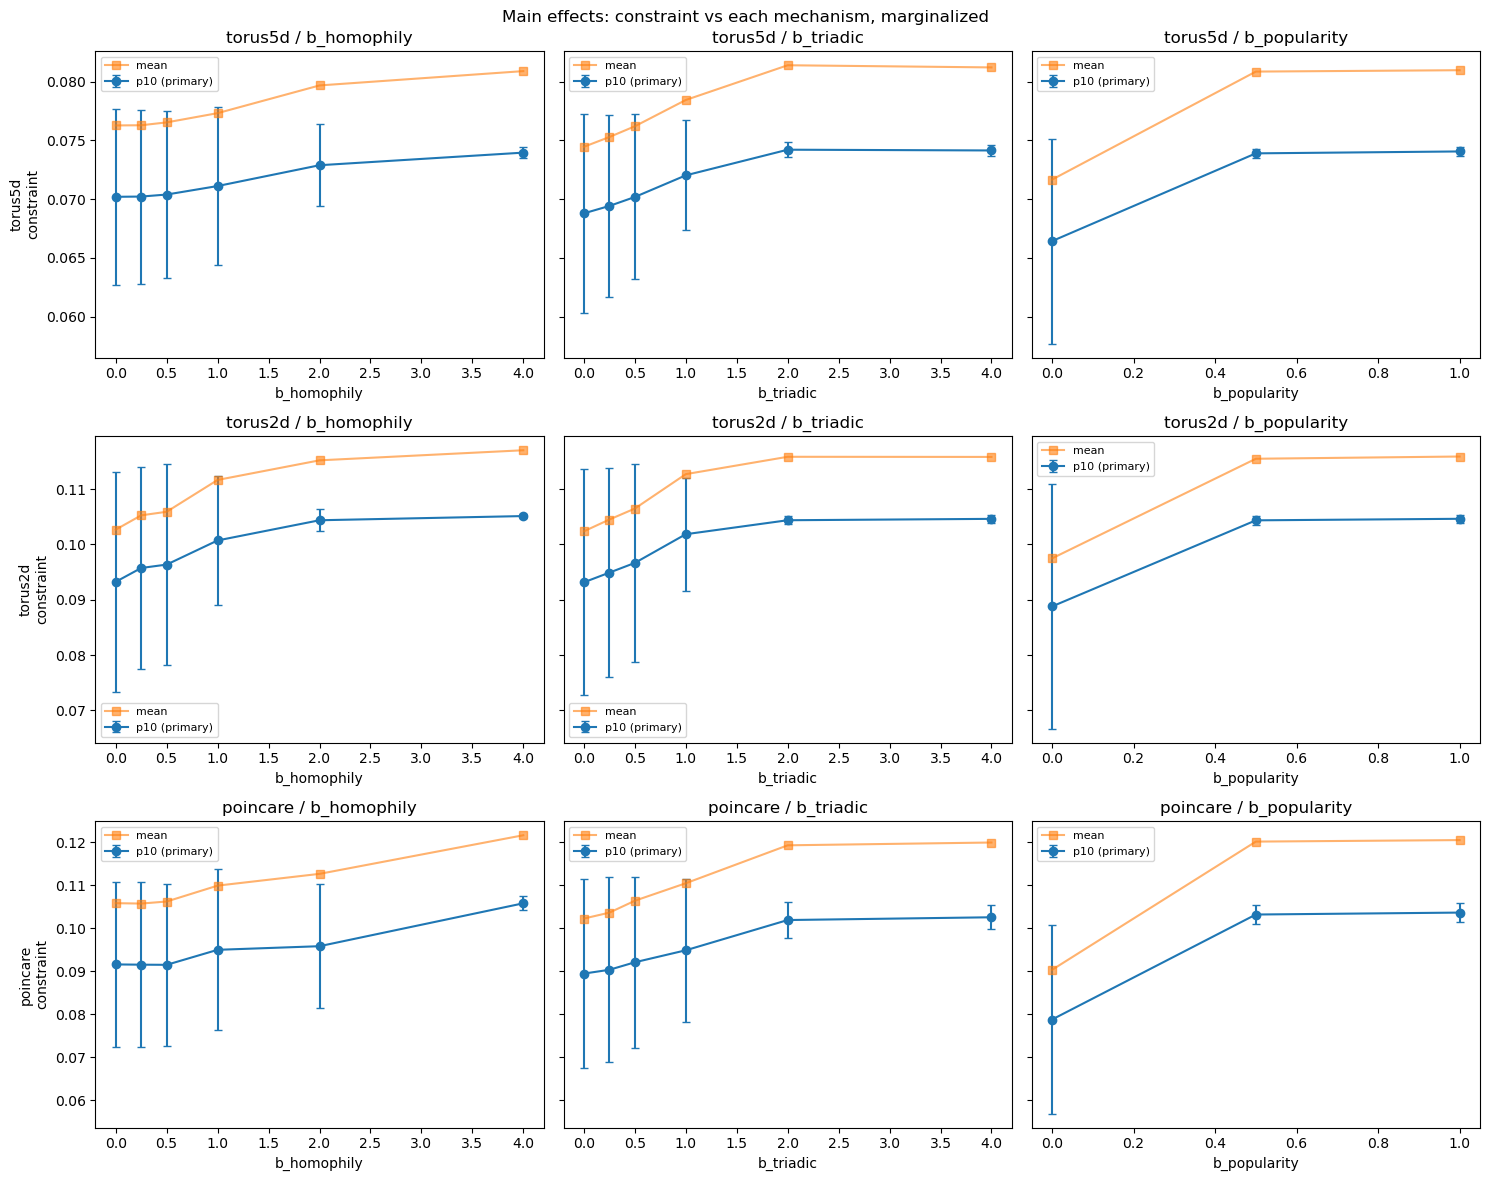

In [17]:
fig, axes = plt.subplots(len(GEOMETRIES), 3, figsize=(15, 4 * len(GEOMETRIES)), sharey="row")
for gi, geo in enumerate(GEOMETRIES):
    sub = end[end["geometry"] == geo]
    for mi, mech in enumerate(("b_homophily", "b_triadic", "b_popularity")):
        ax = axes[gi, mi]
        marg = (sub.groupby(mech)
                   .agg(mean=("p10_constraint", "mean"),
                        std=("p10_constraint", "std"))
                   .reset_index())
        ax.errorbar(marg[mech], marg["mean"], yerr=marg["std"], marker="o", capsize=3,
                    label="p10 (primary)")
        marg_mean = sub.groupby(mech)["mean_constraint"].mean().reset_index()
        ax.plot(marg_mean[mech], marg_mean["mean_constraint"], marker="s", alpha=0.6,
                label="mean")
        ax.set_xlabel(mech)
        if mi == 0:
            ax.set_ylabel(f"{geo}\nconstraint")
        ax.set_title(f"{geo} / {mech}")
        ax.legend(fontsize=8)
plt.suptitle("Main effects: constraint vs each mechanism, marginalized")
plt.tight_layout()
plt.show()


## Cross-geometry comparison

For each mechanism, overlay the three geometry curves to see whether normalization makes them line up — the Stage F prediction from the pilot. If curves align, LEVELS transfer and geometry is a minor factor. If they diverge, geometry-mechanism interaction is a real effect.


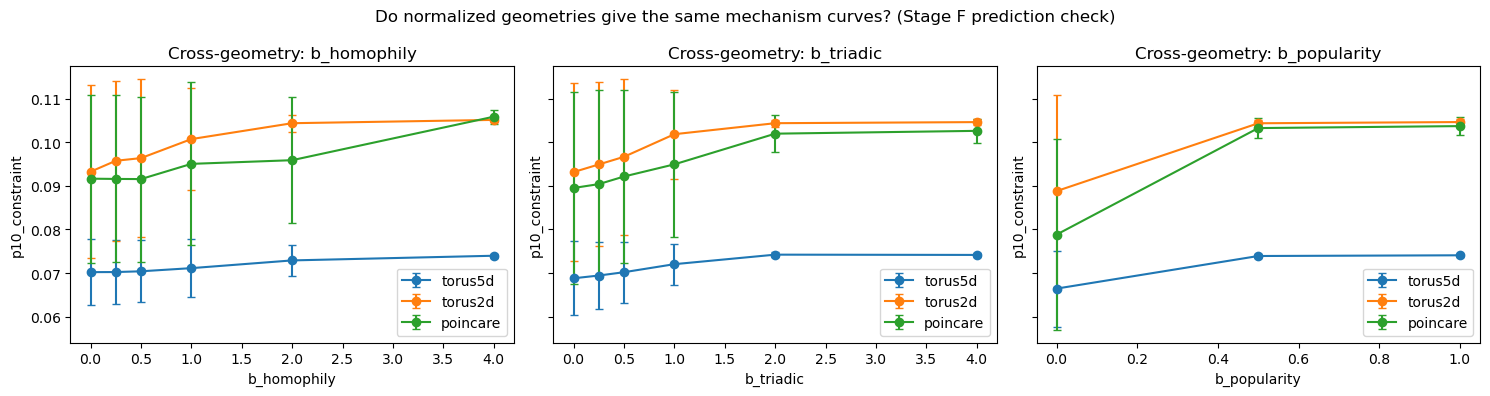

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for mi, mech in enumerate(("b_homophily", "b_triadic", "b_popularity")):
    ax = axes[mi]
    for geo in GEOMETRIES:
        sub = end[end["geometry"] == geo]
        marg = sub.groupby(mech)["p10_constraint"].agg(["mean", "std"]).reset_index()
        ax.errorbar(marg[mech], marg["mean"], yerr=marg["std"], marker="o", capsize=3, label=geo)
    ax.set_xlabel(mech)
    ax.set_ylabel("p10_constraint")
    ax.set_title(f"Cross-geometry: {mech}")
    ax.legend()
plt.suptitle("Do normalized geometries give the same mechanism curves? (Stage F prediction check)")
plt.tight_layout()
plt.show()


## Two-way interaction heatmaps (per geometry)

For each geometry, 2-way heatmaps of `mean_p10_constraint` collapsing over the third mechanism. Non-additive patterns = interactions.


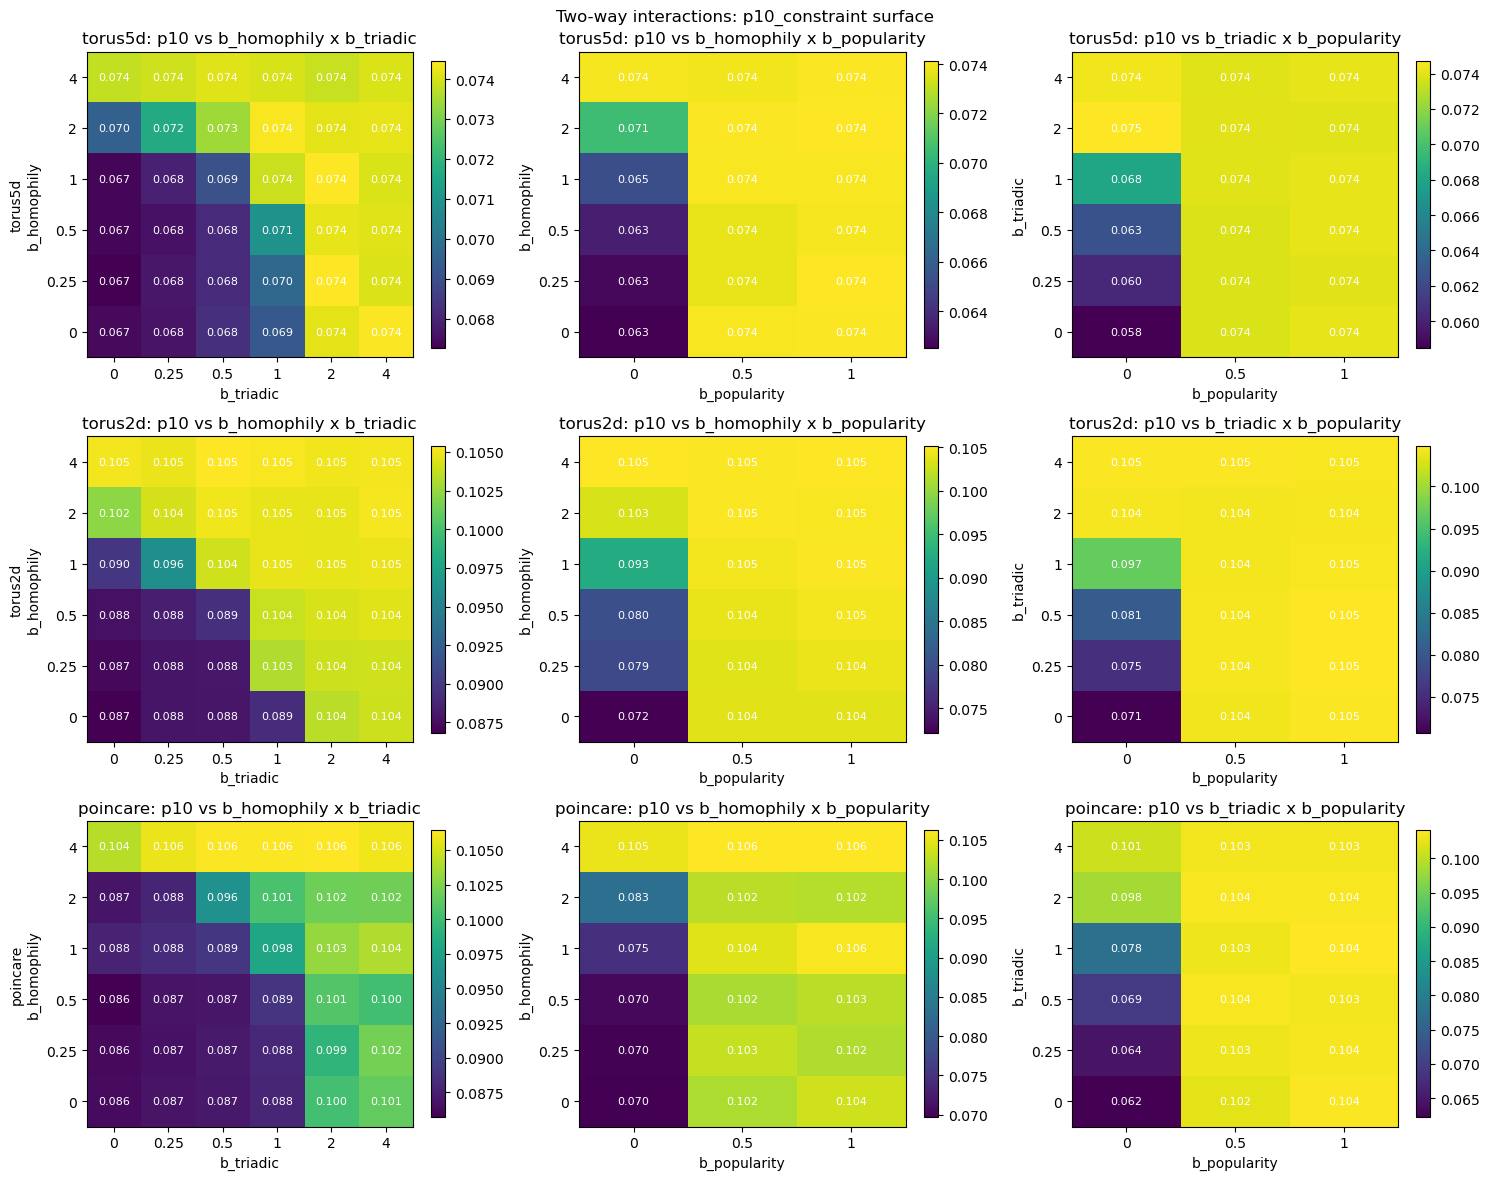

In [19]:
fig, axes = plt.subplots(len(GEOMETRIES), 3, figsize=(15, 4 * len(GEOMETRIES)))
mech_pairs = [("b_homophily", "b_triadic"),
              ("b_homophily", "b_popularity"),
              ("b_triadic", "b_popularity")]

for gi, geo in enumerate(GEOMETRIES):
    sub = end[end["geometry"] == geo]
    for pi, (mx, my) in enumerate(mech_pairs):
        ax = axes[gi, pi]
        grid = (sub.groupby([mx, my])["p10_constraint"]
                   .mean()
                   .unstack(my))
        im = ax.imshow(grid.values, origin="lower", aspect="auto", cmap="viridis")
        ax.set_xticks(range(len(grid.columns)))
        ax.set_xticklabels([f"{v:g}" for v in grid.columns])
        ax.set_yticks(range(len(grid.index)))
        ax.set_yticklabels([f"{v:g}" for v in grid.index])
        ax.set_xlabel(my)
        ax.set_ylabel(f"{geo}\n{mx}" if pi == 0 else mx)
        ax.set_title(f"{geo}: p10 vs {mx} x {my}")
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                ax.text(j, i, f"{grid.values[i, j]:.3f}",
                        ha="center", va="center", color="w", fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.04)
plt.suptitle("Two-way interactions: p10_constraint surface")
plt.tight_layout()
plt.show()


## Three-way interaction (3D)

Full mechanism grid in 3D, one panel per geometry. Each point is a (`b_homophily`, `b_triadic`, `b_popularity`) cell averaged over replicates; axes encode the three coefficients, and **color + size both encode `p10_constraint`**. Dark/small = low constraint (broker-heavy); bright/large = high constraint (embedded). A colorbar is shared across panels (`vmin`/`vmax` pinned to the global range) so geometries are directly comparable.

This is the 3-way analogue of the 2-way heatmaps above: if the grid shows a smooth gradient along one axis, that mechanism has an additive main effect. Hot spots on edges = 2-way interactions (already visible in the heatmaps). Hot spots at corners that the 2-way marginals don't predict = genuine 3-way interactions.


In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  # registers "3d" projection

fig = plt.figure(figsize=(18, 6))
vmin = end["p10_constraint"].min()
vmax = end["p10_constraint"].max()

for gi, geo in enumerate(GEOMETRIES):
    ax = fig.add_subplot(1, len(GEOMETRIES), gi + 1, projection="3d")
    sub = end[end["geometry"] == geo]
    agg = (sub.groupby(["b_homophily", "b_triadic", "b_popularity"])
              ["p10_constraint"]
              .mean()
              .reset_index())
    s_norm = (agg["p10_constraint"] - vmin) / (vmax - vmin + 1e-9)
    sizes = 60 + 400 * s_norm
    sc = ax.scatter(agg["b_homophily"], agg["b_triadic"], agg["b_popularity"],
                    c=agg["p10_constraint"], s=sizes, cmap="viridis",
                    vmin=vmin, vmax=vmax,
                    edgecolors="black", linewidths=0.3, alpha=0.85)
    ax.set_xlabel("b_homophily")
    ax.set_ylabel("b_triadic")
    ax.set_zlabel("b_popularity")
    ax.set_xticks(LEVELS["b_homophily"])
    ax.set_yticks(LEVELS["b_triadic"])
    ax.set_zticks(LEVELS["b_popularity"])
    ax.set_title(geo)
    fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.1, label="p10_constraint")

plt.suptitle("Three-way interaction: p10_constraint across the mechanism grid")
plt.tight_layout()
plt.show()


## Per-node constraint distributions

For three representative cells (baseline / all-mid / all-high) across three geometries, show the per-node constraint histogram at the final snapshot. Brokerage = the left tail.

The dashed vertical line at **C = 0.1** is the brokerage cutoff: nodes with constraint below 0.1 are counted as structural-hole brokers (reported as `frac<0.1` in each panel). This is the same threshold that feeds `p10_constraint` — the 10th percentile of C, used as the primary DV in the main-effects, cross-geometry, and interaction plots above.


In [ ]:
REP_CELLS = {
    "baseline":  (0.0, 0.0, 0.0),
    "all_mid":   (LEVELS["b_homophily"][1], LEVELS["b_triadic"][1], LEVELS["b_popularity"][1]),
    "all_high":  (LEVELS["b_homophily"][2], LEVELS["b_triadic"][2], LEVELS["b_popularity"][2]),
}

def load_constraint(geo, cell_id, rep):
    arr = np.load(RUNS_DIR / f"{geo}_cell{cell_id:02d}_rep{rep}.npz")
    # Final snapshot = last entry in the times array
    return arr["constraint"][-1]

cell_to_idx = {c: i for i, c in enumerate(cells)}

pooled_by_panel = {
    (label, geo): np.concatenate([load_constraint(geo, cell_to_idx[coefs], r)
                                  for r in range(REPLICATES)])
    for label, coefs in REP_CELLS.items()
    for geo in GEOMETRIES
}
all_vals = np.concatenate(list(pooled_by_panel.values()))
xlim = (float(all_vals.min()), float(all_vals.max()))
shared_bins = np.linspace(xlim[0], xlim[1], 41)

# sharex=True gives us genuine x-axis alignment across all 9 panels.
# It also calls label_outer() which hides xlabels + x-tick labels on
# non-bottom rows — we undo that explicitly below so every panel remains labeled.
fig, axes = plt.subplots(len(REP_CELLS), len(GEOMETRIES), figsize=(15, 4 * len(REP_CELLS)),
                         sharex=True, sharey=True)
for ax in axes.flat:
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.xaxis.label.set_visible(True)

for ri, (label, coefs) in enumerate(REP_CELLS.items()):
    for gi, geo in enumerate(GEOMETRIES):
        ax = axes[ri, gi]
        pooled = pooled_by_panel[(label, geo)]
        ax.hist(pooled, bins=shared_bins, alpha=0.8)
        ax.axvline(0.1, color="red", linestyle="--", alpha=0.5,
                   label="C = 0.1 brokerage cutoff")
        ax.set_title(f"{geo} / {label}\n({coefs[0]:g}, {coefs[1]:g}, {coefs[2]:g})")
        ax.set_xlabel("per-node constraint C")
        if gi == 0:
            ax.set_ylabel("count")
        frac_broker = (pooled < 0.1).mean()
        ax.text(0.97, 0.97, f"frac<0.1 = {frac_broker:.2f}",
                ha="right", va="top", transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
        if ri == 0 and gi == 0:
            ax.legend(loc="upper left", fontsize=8)

axes[0, 0].set_xlim(xlim)  # sharex propagates this to all panels
plt.suptitle("Per-node constraint distributions: brokerage tail by geometry x cell")
plt.tight_layout()
plt.show()


## Observations

*Fill this cell after inspecting the plots above.*

### Sanity
- [ ] Baseline has the lowest mean_C per geometry?
- [ ] All-high has the highest mean_C per geometry?
- [ ] Replicate std < 5% of cell means?

### Main effects (per geometry)
- `b_homophily`: …
- `b_triadic`: …
- `b_popularity`: …

### Cross-geometry
- Do normalized curves align (Stage F prediction)? YES / NO / partial for which mechanism?
- If they diverge: which geometry is the outlier and why?

### Interactions
- Strongest 2-way interaction: …
- Does a mechanism only matter when another is off / on?

### Brokerage tail (distributions)
- Which geometry produces the largest left tail at baseline?
- Which cells produce bimodal distributions (two populations: brokers + embedded)?
- Fraction of brokers (`constraint < 0.1`) at (baseline, all-mid, all-high) for each geometry: …

### Next steps
- …
